Reproducing results of the paper: Leave One Out
===============================================

This notebook contains the scripts used to reproduce the results from our paper on the Leave-One-Out estimate of information gains.

In [1]:
import numpy as np
np.random.seed(1)
import os
import sys
import matplotlib.pyplot as plt
# Get the directory where the current notebook is located
NOTEBOOK_DIR = os.getcwd()

# Go up two levels (adjust the '..' count as needed)
REPO_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '../../../../'))

# Add to sys.path if not already there
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
from DisTreebution.UQ.UQ import UQ
import matplotlib

# 1. Qualitative evaluation of Leave One Out

### a. Data generation

In [2]:
def get_data(mode='smooth', n=100, seed=10):
    np.random.seed(seed)
    X = np.random.uniform(0, 10, n)
    a = X*(X>1)+(X<=1)
    scale = (a<6)*a+6*(a>=6)
    y = np.random.gamma(np.sqrt(X), scale=scale)
    if mode=='smooth':
        return X.reshape(-1,1), y
    elif mode=='discontinuous':
        return X.reshape(-1,1), (y+10*(X>=5))
    elif mode=='non-isotonic':
        return X.reshape(-1,1), ((y-2*(X>=7)))
    elif mode=='discrete':
        return X.reshape(-1,1), np.random.poisson(scale, size=n)

from scipy.stats import gamma, poisson
def get_cdf(x_i, vals, mode='smooth'):
    a = x_i*(x_i>1)+(x_i<=1)
    scale = (a<6)*a+6*(a>=6)
    gdcf = gamma.cdf(vals, np.sqrt(x_i), scale=scale)
    if mode=='smooth':
        return gdcf
    elif mode=='discontinuous':
        if x_i<5:
            return gdcf
        else:
            return gamma.cdf(vals-10, np.sqrt(x_i), scale=scale)
    elif mode=='non-isotonic':
        if x_i<7:
            return gdcf
        else:
            return gamma.cdf(vals+2, np.sqrt(x_i), scale=scale)
    elif mode=='discrete':
        return poisson.cdf(vals, scale)
        
mode = 'discontinuous'
X, y = get_data(mode=mode, n=600, seed=20)

# b. CRPS results

100%|█████████████████████████████████████████| 100/100 [00:14<00:00,  6.91it/s]
/tmp/ipykernel_197042/2934218826.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = matplotlib.cm.get_cmap('Greys')


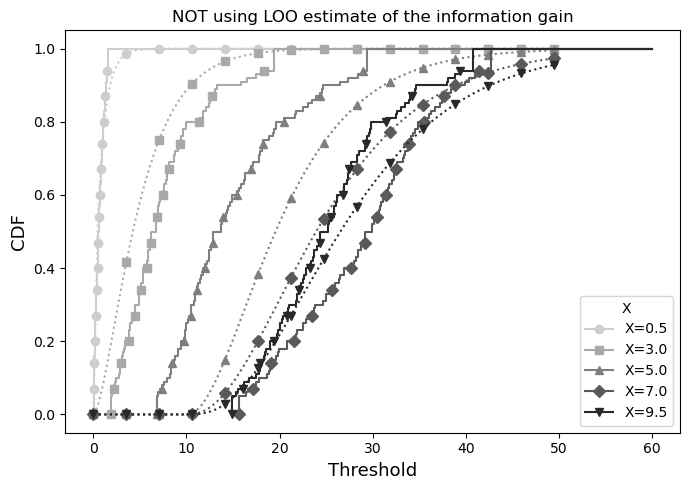

100%|█████████████████████████████████████████| 100/100 [00:09<00:00, 10.27it/s]


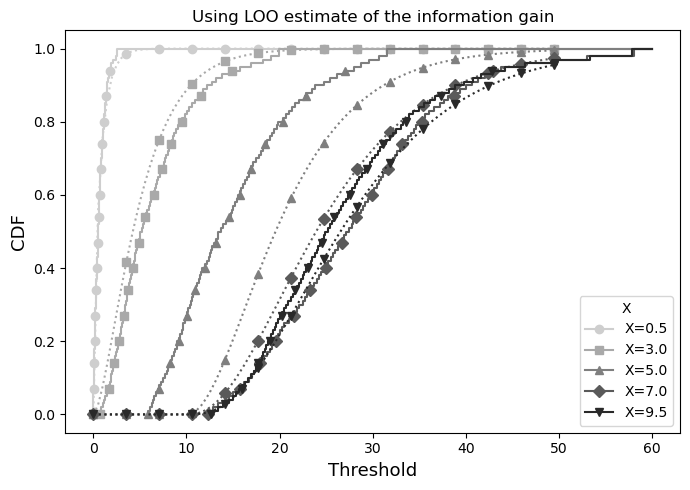

In [4]:
ls_q = [0.01*(i+1) for i in range(99)]
markers = ['o', 's', '^', 'D', 'v']  # distinct markers for each x_test
styles = ['-', '--', ':', '-.', (0, (3, 10, 1, 10))]

for use_LOO in [False, True]:
    if not(use_LOO):
        IG_mode = None
    else:
        IG_mode = "LOO"
    params = {'IG_biais_correction':IG_mode, 'nTrees':100, 'max_depth':10, 'min_samples_split':10}
    
    model = UQ(type_tree='CRPS', type_conformal=None, params=params)
    treesCRPSRT, _ = model.train_trees(X.reshape(-1,1), y)
    
    x_test = np.array([0.5, 3, 5, 7, 9.5]).reshape(-1,1)
    resCRPSRT = model.get_quantile_estimate(treesCRPSRT, x_test, ls_q)
    
    plt.figure(figsize=(7,5))
    
    # Use a sequential gray colormap
    cmap = matplotlib.cm.get_cmap('Greys')
    
    for i, x_i in enumerate(x_test[:,0]):
        ls_x = []
        ls_y = []
        for i_q, q in enumerate(ls_q[:-1]):
            ls_x += [resCRPSRT[i][i_q], resCRPSRT[i][i_q], resCRPSRT[i][i_q+1]]
            if i_q==0:
                ls_y += [0, q, q]
            else:
                ls_y += [ls_q[i_q-1], q, q]
        ls_x.append(resCRPSRT[i][len(ls_q)-1])
        ls_y.append(1)
        ls_x.append(60)
        ls_y.append(1)
        
        color = cmap(0.3 + 0.7 * i / x_test.shape[0])  # shades of gray
        plt.plot(ls_x, ls_y, color=color, linestyle='-', marker=markers[i % len(markers)],
                 markevery=20, markersize=6, label=f'X={x_i}')
        
        # Theoretical CDF as dotted line with same shade
        vals = np.linspace(0,50,100)
        plt.plot(vals, get_cdf(x_i, vals, mode=mode), color=color, marker=markers[i % len(markers)], markevery=7, linestyle=':')
    
    plt.legend(title='X', fontsize=10)
    plt.xlabel('Threshold', fontsize=13)
    plt.ylabel('CDF', fontsize=13)
    
    if use_LOO:
        plt.title('Using LOO estimate of the information gain')
    else:
        plt.title('NOT using LOO estimate of the information gain')
    plt.tight_layout()
    plt.show()


### c. PMQRTs results

100%|█████████████████████████████████████████| 100/100 [01:14<00:00,  1.34it/s]
/tmp/ipykernel_197042/2356336621.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = matplotlib.cm.get_cmap('winter')


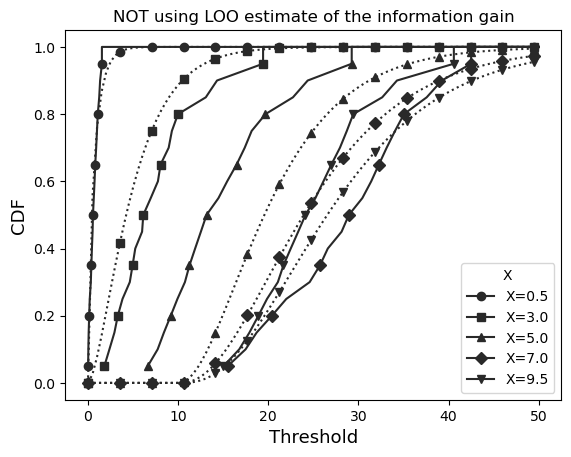

100%|█████████████████████████████████████████| 100/100 [01:09<00:00,  1.43it/s]


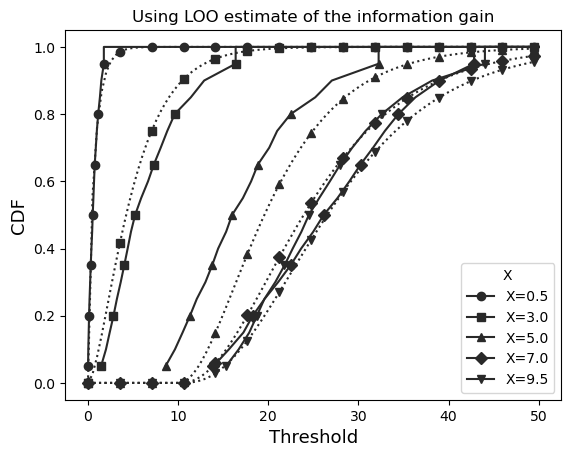

In [5]:
ls_q = [0.05*(i+1) for i in range(19)]
for use_LOO in [False, True]:
    if not(use_LOO):
        IG_mode = None
    else:
        IG_mode = "LOO"
    params = {'IG_biais_correction':IG_mode, 'nTrees':100, 'max_depth':7, 'min_samples_split':10, 'treeID2quantiles_train':{ID : ls_q for ID in range(100)}}
    
    model = UQ(type_tree='PMQRT', type_conformal=None, params=params)
    treesPQRT, _ = model.train_trees(X.reshape(-1,1), y)
    
    x_test = np.array([0.5, 3, 5, 7, 9.5]).reshape(-1,1)
    resPQRT = model.get_quantile_estimate(treesPQRT, x_test, ls_q)
    import matplotlib
    cmap = matplotlib.cm.get_cmap('winter')
    for i, x_i in enumerate(x_test[:,0]):
        ls = []
        ls_x = []
        ls_y = []
        for i_q, q in enumerate(ls_q):
            ls_x +=  [resPQRT[i][i_q]]
            if i_q==0:
                ls_y.append(q)
            else:
                ls_y.append(q)
        #plt.scatter(ls_x, ls_y, color=cmap(i/x_test.shape[0]))
        ls_x.append(resPQRT[i][len(ls_q)-1])
        ls_y.append(1)
        ls_x.append(50)
        ls_y.append(1)
        plt.plot(ls_x, ls_y, color=color, linestyle='-', marker=markers[i % len(markers)],
                 markevery=3, markersize=6, label=f'X={x_i}')
        vals = np.linspace(0,50,100)
        
        plt.plot(vals, get_cdf(x_i, vals, mode=mode), color=color, marker=markers[i % len(markers)], markevery=7, linestyle=':')

        #plt.plot(vals, get_cdf(x_i, vals, mode=mode), color=cmap(i/x_test.shape[0]), linestyle='--', label=str(x_i))
    plt.legend(title='X')
    plt.xlabel('Threshold', fontsize=13)
    plt.ylabel('CDF', fontsize=13)
    if use_LOO:
        plt.title('Using LOO estimate of the information gain')
    else:
        plt.title('NOT using LOO estimate of the information gain')
    plt.show()

# 2. Quantitative evaluation of Leave One Out and Mallows correction

This section presents the results of experiments conducted on various datasets to quatify the effect of using Leave One Out (LOO) or Mallows estimates of information gain in the training CRPS-RF when considering different values of standard stopping criteria.

In [ ]:
max_depths = [i for i in range(1,14)]
min_samples_splits = [5*(i+1) for i in range(10)]
noLOO = {"width": np.zeros((len(max_depths), len(min_samples_splits))), "coverage": np.zeros((len(max_depths), len(min_samples_splits)))}
LOO = {"width": np.zeros((len(max_depths), len(min_samples_splits))), "coverage": np.zeros((len(max_depths), len(min_samples_splits)))}
Mallows = {"width": np.zeros((len(max_depths), len(min_samples_splits))), "coverage": np.zeros((len(max_depths), len(min_samples_splits)))}
seed = 0
x_test, y_test = get_data(mode=mode, n=1000, seed=0)
alpha = 0.1
from tqdm import tqdm
for idxdepth, max_depth in tqdm(enumerate(max_depths)):
    print('MAX DEPTH', max_depth)
    for idxsplit, min_samples_split in enumerate(min_samples_splits):
        for IG_biais_correction in [None, "LOO", "Mallows"]:
            params = {'IG_biais_correction':IG_biais_correction, 'nTrees':100, 'max_depth':max_depth, 'min_samples_split':min_samples_split}
            model = UQ(type_tree='CRPS', type_conformal=None, params=params)
            treesCRPSRT, _ = model.train_trees(X.reshape(-1,1), y)
            resCRPSRT = model.get_quantile_estimate(treesCRPSRT, x_test, [alpha/2, 1-alpha/2])
            widths, coverages = model.compute_width_coverage(resCRPSRT, y_test)
            if IG_biais_correction == "LOO":
                LOO["width"][idxdepth,idxsplit] = np.mean(widths)
                LOO["coverage"][idxdepth,idxsplit] = np.mean(coverages)
            elif IG_biais_correction == "Mallows":
                Mallows["width"][idxdepth,idxsplit] = np.mean(widths)
                Mallows["coverage"][idxdepth,idxsplit] = np.mean(coverages)
            else:
                noLOO["width"][idxdepth,idxsplit] = np.mean(widths)
                noLOO["coverage"][idxdepth,idxsplit] = np.mean(coverages)

In [ ]:
def write_latex_table_v2(metric_name, no_correction_data, LOO_data, Mallows_data, max_depths, min_samples_splits, filename=None):
    """
    Generate a LaTeX table comparing no correction, LOO, and Mallows.
    Rows = min_samples_split, with one row per correction type per min_samples_split.
    Columns = max_depth values.
    """
    table = []
    table.append("\\begin{table}[h!]")
    table.append("\\centering")
    table.append(f"\\caption{{Comparison of {metric_name} between no correction, LOO, and Mallows across max depth and min_samples_split}}")
    table.append("\\scriptsize")
    table.append("\\setlength{\\tabcolsep}{3pt}")
    table.append("\\renewcommand{\\arraystretch}{1.1}")

    # Column specification: 2 + len(max_depths) columns
    table.append("\\begin{tabular}{|c|c|" + "c|"*len(max_depths) + "}")
    table.append("\\hline")
    table.append("\\multirow{2}{*}{min\\_samples} & \\multirow{2}{*}{Correction} & " + " & ".join([str(d) for d in max_depths]) + " \\\\")
    table.append("\\cline{3-" + str(2+len(max_depths)) + "}")
    table.append(" & & " + " & ".join([str(d) for d in max_depths]) + " \\\\")  # optional, or can skip
    table.append("\\hline\\hline")

    # Data rows
    for i, mss in enumerate(min_samples_splits):
        # no correction row
        row_no = [str(mss), "no correction"] + [f"{val:.3f}" for val in no_correction_data[:, i]]
        table.append(" & ".join(row_no) + " \\\\")
        # LOO row
        row_LOO = [str(mss), "LOO"] + [f"{val:.3f}" for val in LOO_data[:, i]]
        table.append(" & ".join(row_LOO) + " \\\\")
        # Mallows row
        row_M = [str(mss), "Mallows"] + [f"{val:.3f}" for val in Mallows_data[:, i]]
        table.append(" & ".join(row_M) + " \\\\")
        table.append("\\hline")

    table.append("\\end{tabular}")
    table.append("\\end{table}")

    latex_code = "\n".join(table)

    if filename:
        with open(filename, "w") as f:
            f.write(latex_code)

    return latex_code

In [ ]:
latex_width = write_latex_table_v2("mean width", noLOO["width"], LOO["width"], Mallows["width"], max_depths, min_samples_splits)
latex_coverage = write_latex_table_v2("mean coverage", noLOO["coverage"], LOO["coverage"], Mallows["coverage"], max_depths, min_samples_splits)

print(latex_width)
print("\n" + "="*80 + "\n")
print(latex_coverage)